In [2]:
import math
import numpy as np
import matplotlib.pyplot as plt
import random

In [3]:
class Value:

    def __init__(self, data, children=(), op='', label=''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(children)
        self.op = op
        self.label = label

    def __repr__(self):
        return f'Value({self.data})'

    def __add__(self, other):
        other = other if type(other) == Value else Value(other)
        out = Value(self.data + other.data, (self, other,), '+')

        def _backward():
            self.grad += out.grad
            other.grad += out.grad

        out._backward = _backward
        return out

    def __radd__(self, other):
        return self + other

    def __mul__(self, other):
        other = other if type(other) == Value else Value(other)
        out = Value(self.data * other.data, (self, other,), '*')

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad

        out._backward = _backward
        return out

    def __rmul__(self, other):
        return self * other

    def __neg__(self):
        return self * -1

    def __sub__(self, other):
        return self + (-other)

    def __rsub__(self, other):
        return other + (-self)

    def __pow__(self, other):
        assert isinstance(other, (int, float)), 'only supports int/float'
        out = Value(self.data**other, (self,), f'**{other}')

        def _backward():
            self.grad += out.grad * (other * self.data**(other-1))

        out._backward = _backward
        return out

    def __truediv__(self, other):
        return self * other**-1

    def exp(self):
        out = Value(math.exp(self.data), (self,), 'exp')

        def _backward():
            self.grad += out.grad * out.data

        out._backward = _backward
        return out

    def tanh(self):
        out = Value(math.tanh(self.data), (self,), 'tanh')

        def _backward():
            self.grad += out.grad * (1 - out.data**2)

        out._backward = _backward
        return out
    
    def ReLU(self):
        out = Value(max(self.data, 0), (self,), 'ReLU')

        def _backward():
            if self.data > 0:
                self.grad += out.grad
        
        out._backward = _backward
        return out
    
    def leakyReLU(self, alpha):
        out = Value(self.data , (self, ), 'leakyReLU')
        if self.data <= 0:
            out.data *= alpha
        
        def _backward():
            if self.data <= 0:
                self.grad += out.grad * alpha
            else:
                self.grad += out.grad
        
        out._backward = _backward
        return out
    
    def sigmoid(self):
        out = Value(1/(1 + math.exp(-self.data)), (self, ), 'sigmoid')

        def _backward():
            self.grad += out.grad * (out.data * (1 - out.data))

        out._backward = _backward
        return out
    
    def swish(self):
        out = Value(self.data * self.sigmoid().data, (self,), 'swish')

        def _backward():
            self.grad += out.grad * (out.data + self.data * (1 - out.data))

        out._backward = _backward
        return out
    
    def backward(self):

        tops = []
        used = set()
        
        def dfs(v):
            if v not in used:
                used.add(v)
                for to in v._prev:
                    dfs(to)
                tops.append(v)

        self.grad = 1.0
        dfs(self)
        for v in reversed(tops):
            v._backward()


In [4]:
# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'

In [5]:
o

Value(0.7071067811865476)

In [6]:
class Neuron:

    def __init__(self, ins):
        self.w = [Value(random.uniform(-1, 1)) for _ in range(ins)]
        self.b = Value(random.uniform(-1, 1))

    def __call__(self, x):
        return (sum(wi*xi for wi, xi in zip(self.w, x)) + self.b).tanh()

    def parameters(self):
        return self.w + [self.b]

class Layer:

    def __init__(self, ins, outs):
        self.neurons = [Neuron(ins) for _ in range(outs)]

    def __call__(self, x):
        res = [neuron(x) for neuron in self.neurons]
        return res[0] if len(res) == 1 else res

    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.parameters()]

class MLP:

    def __init__(self, ins, szs):
        sz = [ins] + szs
        self.layers = [Layer(i, j) for i, j in zip(sz, sz[1:])]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

In [7]:
Perc = MLP(3, [4, 4, 1])

In [8]:
xs = [
  [2.0, 3.0, -1.0],
  [3.0, -1.0, 0.5],
  [0.5, 1.0, 1.0],
  [1.0, 1.0, -1.0],
]
ys = [1.0, -0.5, -1.0, 0.5]

In [9]:
for _ in range(100):
    y_pred = [Perc(x) for x in xs]

    loss = sum((y_p - y_t)**2 for y_p, y_t in zip(y_pred, ys))

    print(_, loss)
    
    for p in Perc.parameters():
        p.grad = 0.0

    loss.backward()

    for p in Perc.parameters():
        p.data -= 0.1 * p.grad

0 Value(2.821328265458137)
1 Value(2.0276421836192604)
2 Value(1.6661047438214913)
3 Value(1.3234089612895397)
4 Value(1.8158794283998791)
5 Value(4.226495162559689)
6 Value(1.909499799089947)
7 Value(0.7452244948325256)
8 Value(0.34040322665253864)
9 Value(0.2936067286251456)
10 Value(0.261002694618123)
11 Value(0.23190702811849387)
12 Value(0.21037665625028895)
13 Value(0.19873351955185248)
14 Value(0.1925951111068681)
15 Value(0.18793179432489163)
16 Value(0.18374562109774284)
17 Value(0.17989548913387898)
18 Value(0.17633029880526205)
19 Value(0.17301038072170638)
20 Value(0.16990179251102935)
21 Value(0.1669751580136581)
22 Value(0.16420491131813164)
23 Value(0.16156867142171552)
24 Value(0.1590467113778666)
25 Value(0.15662150749207693)
26 Value(0.1542773570466895)
27 Value(0.1520000541672245)
28 Value(0.14977661459881367)
29 Value(0.1475950414084135)
30 Value(0.14544412487868394)
31 Value(0.14331327105543545)
32 Value(0.14119235453071213)
33 Value(0.13907159209035655)
34 Value(0

In [10]:
y_pred

[Value(0.9526819274751074),
 Value(-0.5108648590367381),
 Value(-0.9225201779299207),
 Value(0.5068169044471055)]

In [11]:
Xtr = [[0, 0], [0, 1], [1, 0], [1, 1]]
Ytr = [0, 1, 1, 0]

xor_model = MLP(2, [4, 1])

In [12]:
for _ in range(1000):
    y_pred = [xor_model(x) for x in Xtr]

    loss = sum((y - y_p)**2 for y, y_p in zip(Ytr, y_pred))
    print(f'{_}', loss)

    for p in xor_model.parameters():
        p.grad = 0.0

    loss.backward()

    for p in xor_model.parameters():
        p.data -= 0.1 * p.grad

0 Value(4.062718711406559)
1 Value(1.4213688906088966)
2 Value(1.2273275813411468)
3 Value(1.0428525600953709)
4 Value(0.9672579718638395)
5 Value(0.9486170166169621)
6 Value(0.9340162014046336)
7 Value(0.9212068288570194)
8 Value(0.9095252929698987)
9 Value(0.8985436672527933)
10 Value(0.8879774203368114)
11 Value(0.87763175654835)
12 Value(0.8673684387179627)
13 Value(0.8570850783116194)
14 Value(0.8467023531710705)
15 Value(0.8361561686883311)
16 Value(0.8253928718485984)
17 Value(0.814366346151188)
18 Value(0.8030362703050395)
19 Value(0.7913671072254513)
20 Value(0.7793275624195387)
21 Value(0.7668903541852532)
22 Value(0.7540321985834167)
23 Value(0.740733946550561)
24 Value(0.7269808291304923)
25 Value(0.7127627759764462)
26 Value(0.6980747760180106)
27 Value(0.682917250069419)
28 Value(0.6672964049222129)
29 Value(0.651224538329881)
30 Value(0.6347202651066917)
31 Value(0.6178086368677087)
32 Value(0.6005211319786435)
33 Value(0.5828954980197857)
34 Value(0.5649754361938658)
35

In [13]:
y_pred

[Value(0.0007588281220915461),
 Value(0.9808615007394577),
 Value(0.9802030520755304),
 Value(0.0009349479139455662)]

In [20]:
Xtr = [[_] for _ in range(-20, 21)]
Ytr = [math.sin(_[0]) for _ in Xtr]

sin_model = MLP(1, [16, 16, 1])

Value(1.2683460462241)
Value(0.5046294384132191)
Value(0.4715162689489511)
Value(0.44648570383749386)
Value(0.42150744267773804)
Value(0.40663989523910365)
Value(0.39719291838012)
Value(0.3875197424733668)
Value(0.37915321204212693)
Value(0.37489264328073496)


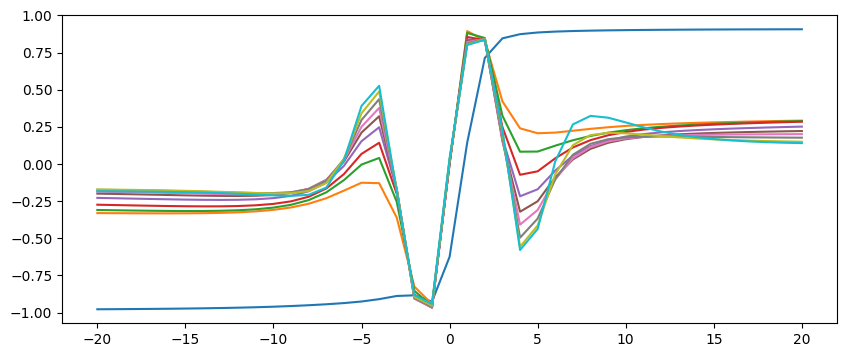

In [21]:
plt.figure(figsize=(10, 4))
for _ in range(1000):
    y_pred = [sin_model(x) for x in Xtr]

    loss = sum((y - y_p)**2 for y, y_p in zip(Ytr, y_pred))/len(Xtr)

    if(_ % 100 == 0):
        plt.plot([x for x in Xtr], [y.data for y in y_pred])
        print(loss)

    for p in sin_model.parameters():
        p.grad = 0.0

    loss.backward()

    for p in sin_model.parameters():
        p.data -= 0.1 * p.grad

plt.show()

In [22]:
Xte = np.linspace(-30, 30, 100)
Yte = [math.sin(_) for _ in Xte]

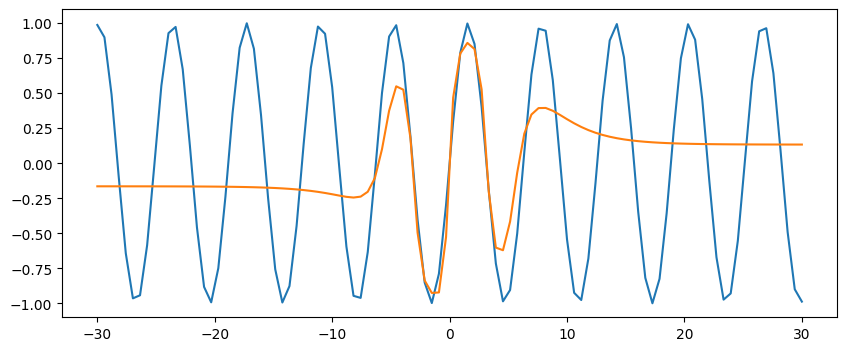

In [23]:
plt.figure(figsize=(10, 4))
plt.plot(Xte, Yte)
plt.plot(Xte, [sin_model([x]).data for x in Xte])
plt.show()